# Q3 Part 4 – Field Colour Plots

Produce field $x$–$y$ colour (pcolormesh) plots with contours of:
- $\phi_x$ (streamwise velocity perturbation)
- $\phi_y$ (normal velocity perturbation)
- $\psi = K - (\gamma+1)\phi_x$ (elliptic/hyperbolic type indicator)

for selected K values, highlighting the sonic line ($\psi=0$) where it exists.

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from q3_solver import (
    solve, compute_phi_x, compute_phi_y, compute_psi,
    surface_phi_x, GAMMA
)

K_plot = [5.0, 2.5, 1.8, 1.2]
Nx, Ny = 161, 81
q, s, r = 5.0, 5.0, 5.0
TOL = 1e-6
MAX_ITER = 80000

Solve for each K

In [201]:
solutions = {}
phi_prev = None
K_all = sorted(set(K_plot), reverse=True)

for K in K_all:
    print(f"\n--- K = {K} ---")
    use_elliptic = (K >= 3.5)
    phi, info = solve(K, Nx=Nx, Ny=Ny, q=q, s=s, r=r,
                      tol=TOL, max_iter=MAX_ITER, check_every=200,
                      elliptic_only=use_elliptic,
                      phi_init=phi_prev, verbose=True)

    if not info["converged"] and use_elliptic:
        print("Retrying with transonic switching...")
        phi, info = solve(K, Nx=Nx, Ny=Ny, q=q, s=s, r=r,
                          tol=TOL, max_iter=MAX_ITER, check_every=200,
                          elliptic_only=False,
                          phi_init=phi_prev, verbose=True)

    solutions[K] = (phi, info)
    phi_prev = phi


--- K = 5.0 ---
  it      1  |res|=1.847e+01  |upd|=1.425e-02  t=0.0s
  it   2000  |res|=2.931e-02  |upd|=3.220e-05  t=14.9s
  it   4000  |res|=1.134e-02  |upd|=1.251e-05  t=29.6s
  it   6000  |res|=4.976e-03  |upd|=5.500e-06  t=44.1s
  it   8000  |res|=2.334e-03  |upd|=2.584e-06  t=58.9s
  it  10000  |res|=1.144e-03  |upd|=1.268e-06  t=73.6s
  it  12000  |res|=5.774e-04  |upd|=6.407e-07  t=88.5s
  it  14000  |res|=2.975e-04  |upd|=3.305e-07  t=103.3s
  it  16000  |res|=1.553e-04  |upd|=1.727e-07  t=117.8s
  it  18000  |res|=8.179e-05  |upd|=9.105e-08  t=132.3s
  it  20000  |res|=4.329e-05  |upd|=4.824e-08  t=147.1s
  it  22000  |res|=2.299e-05  |upd|=2.564e-08  t=162.0s
  it  24000  |res|=1.223e-05  |upd|=1.366e-08  t=177.0s
  it  26000  |res|=6.525e-06  |upd|=7.284e-09  t=191.8s
  it  28000  |res|=3.488e-06  |upd|=3.887e-09  t=206.5s
  it  30000  |res|=1.865e-06  |upd|=2.075e-09  t=221.1s
  it  32000  |res|=9.981e-07  |upd|=1.108e-09  t=235.5s
  Converged at it=32000, |res|=9.981e-0

Field plots for each K

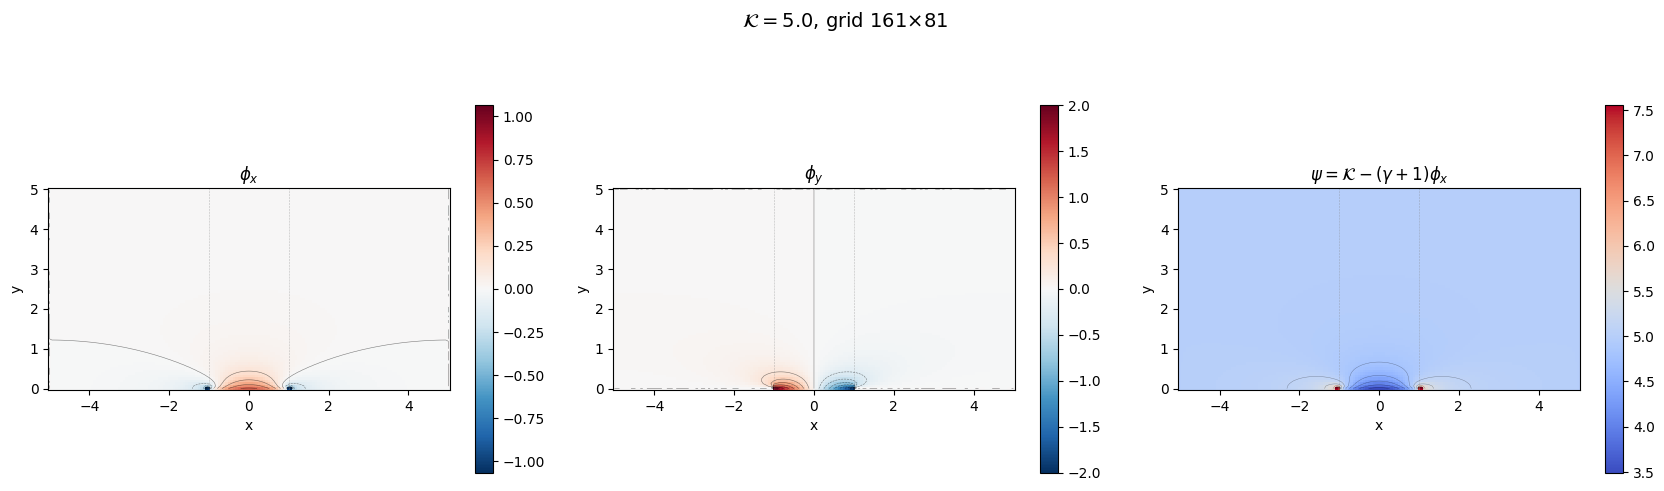

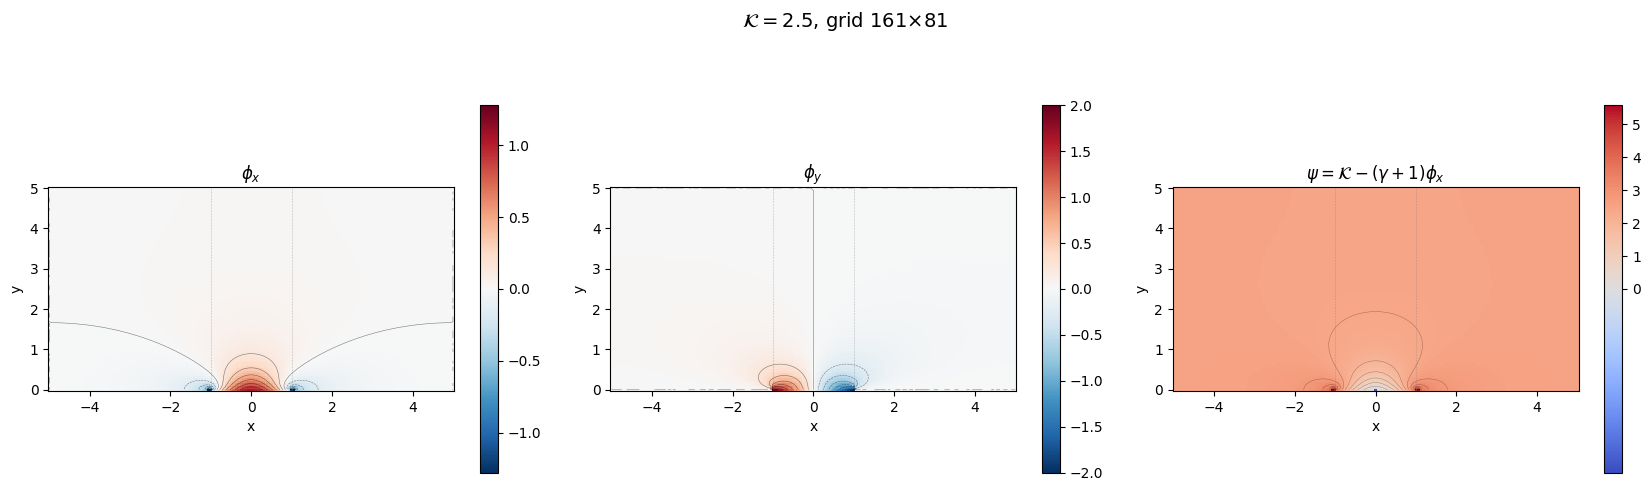

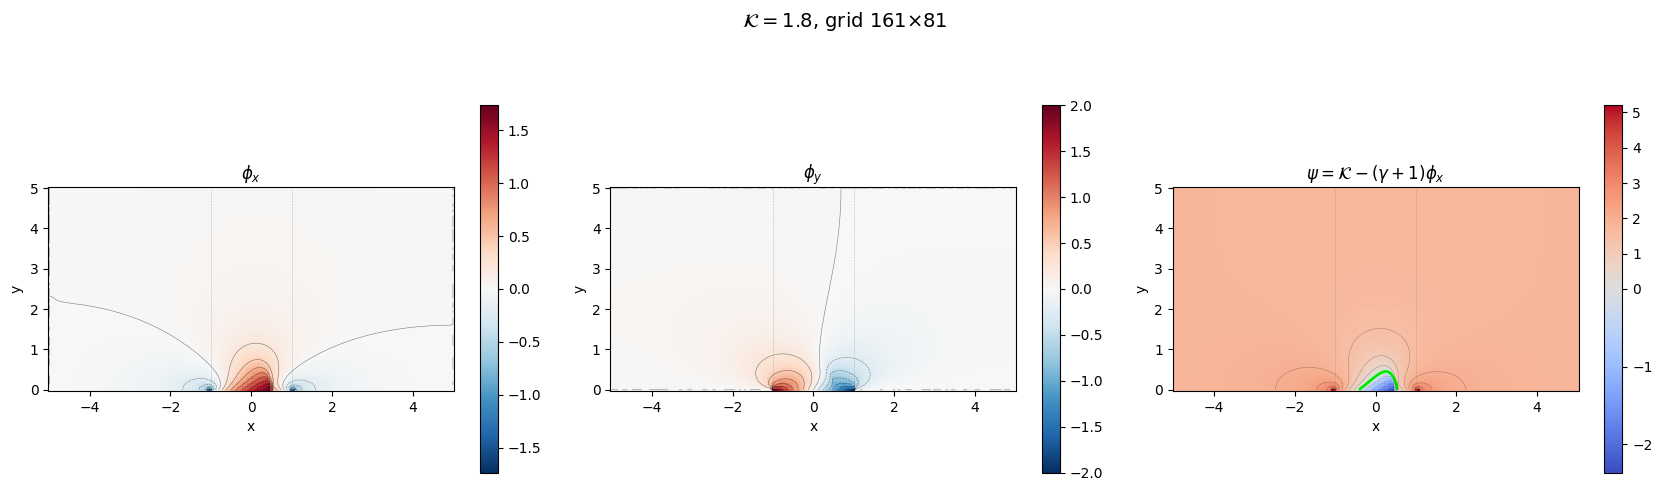

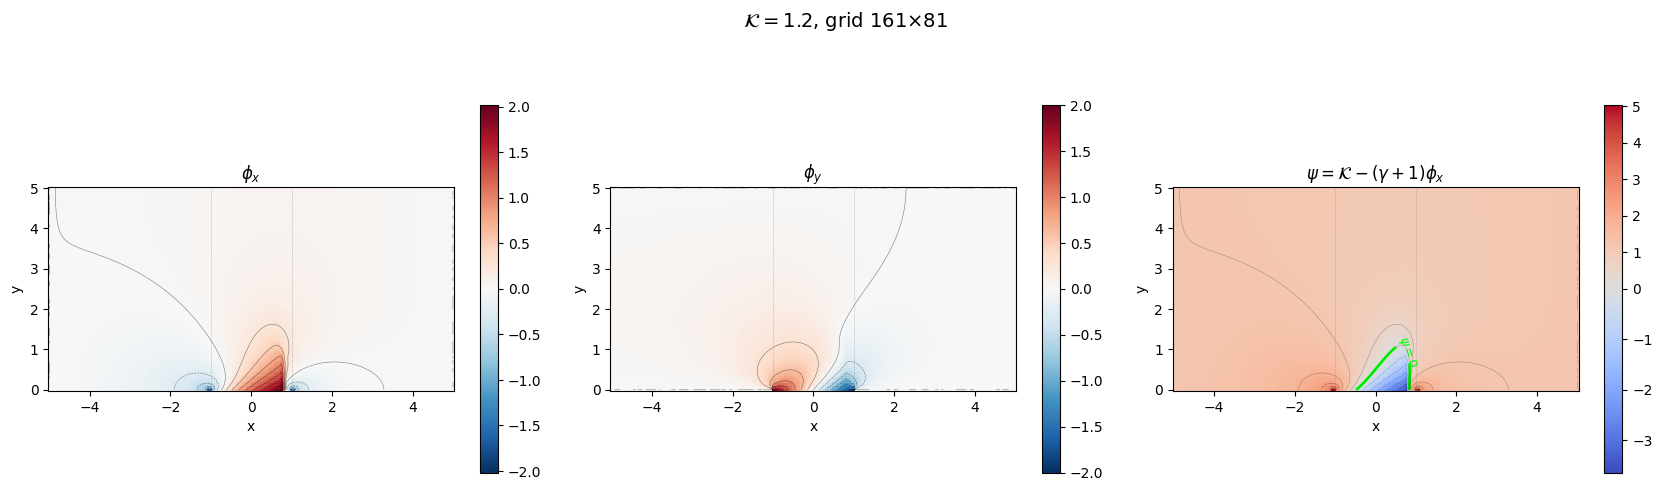

In [205]:
for K in K_plot:
    phi, info = solutions[K]
    x = info["x"]; y = info["y"]
    dx, dy = info["dx"], info["dy"]
    X, Y = np.meshgrid(x, y, indexing="ij")

    phi_x = compute_phi_x(phi, dx)
    phi_y = compute_phi_y(phi, dy)
    psi   = compute_psi(phi_x, K)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(rf"$\mathcal{{K}} = {K}$, grid {Nx}×{Ny}", fontsize=14, y=1.02)

    # phi_x
    vmax_x = max(abs(phi_x.min()), abs(phi_x.max()))
    if vmax_x < 1e-10: vmax_x = 1.0
    norm_x = TwoSlopeNorm(vmin=-vmax_x, vcenter=0, vmax=vmax_x)
    c0 = axes[0].pcolormesh(X, Y, phi_x, shading="auto", cmap="RdBu_r", norm=norm_x)
    axes[0].contour(X, Y, phi_x, levels=15, colors="k", linewidths=0.4, alpha=0.5)
    axes[0].set_title(r"$\phi_x$", fontsize=12)
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    plt.colorbar(c0, ax=axes[0], shrink=0.85)

    # phi_y
    vmax_y = max(abs(phi_y.min()), abs(phi_y.max()))
    if vmax_y < 1e-10: vmax_y = 1.0
    norm_y = TwoSlopeNorm(vmin=-vmax_y, vcenter=0, vmax=vmax_y)
    c1 = axes[1].pcolormesh(X, Y, phi_y, shading="auto", cmap="RdBu_r", norm=norm_y)
    axes[1].contour(X, Y, phi_y, levels=15, colors="k", linewidths=0.4, alpha=0.5)
    axes[1].set_title(r"$\phi_y$", fontsize=12)
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    plt.colorbar(c1, ax=axes[1], shrink=0.85)

    # psi
    psi_min_val = psi.min(); psi_max_val = psi.max()
    if psi_min_val < 0 and psi_max_val > 0:
        norm_psi = TwoSlopeNorm(vmin=psi_min_val, vcenter=0, vmax=psi_max_val)
    else:
        norm_psi = None
    c2 = axes[2].pcolormesh(X, Y, psi, shading="auto", cmap="coolwarm", norm=norm_psi)
    if psi_min_val < 0:
        cs = axes[2].contour(X, Y, psi, levels=[0], colors="lime", linewidths=2.0)
        axes[2].clabel(cs, fmt=r"$\psi=0$", fontsize=9)
    axes[2].contour(X, Y, psi, levels=15, colors="k", linewidths=0.3, alpha=0.4)
    axes[2].set_title(r"$\psi = \mathcal{K} - (\gamma+1)\phi_x$", fontsize=12)
    axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
    plt.colorbar(c2, ax=axes[2], shrink=0.85)

    for ax in axes:
        ax.set_aspect("equal")
        ax.axvline(-1, color="grey", ls="--", lw=0.4, alpha=0.5)
        ax.axvline( 1, color="grey", ls="--", lw=0.4, alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"q3_p4_fields_K{K:.1f}.png", dpi=150, bbox_inches="tight")
    plt.show()

Combined $\psi$ plot showing sonic line evolution

<>:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/7p/mb_tr2r90hbfsz2r254_x_d40000gn/T/ipykernel_15704/4100486897.py:30: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  "\n(green line = sonic line $\psi=0$)", fontsize=14)


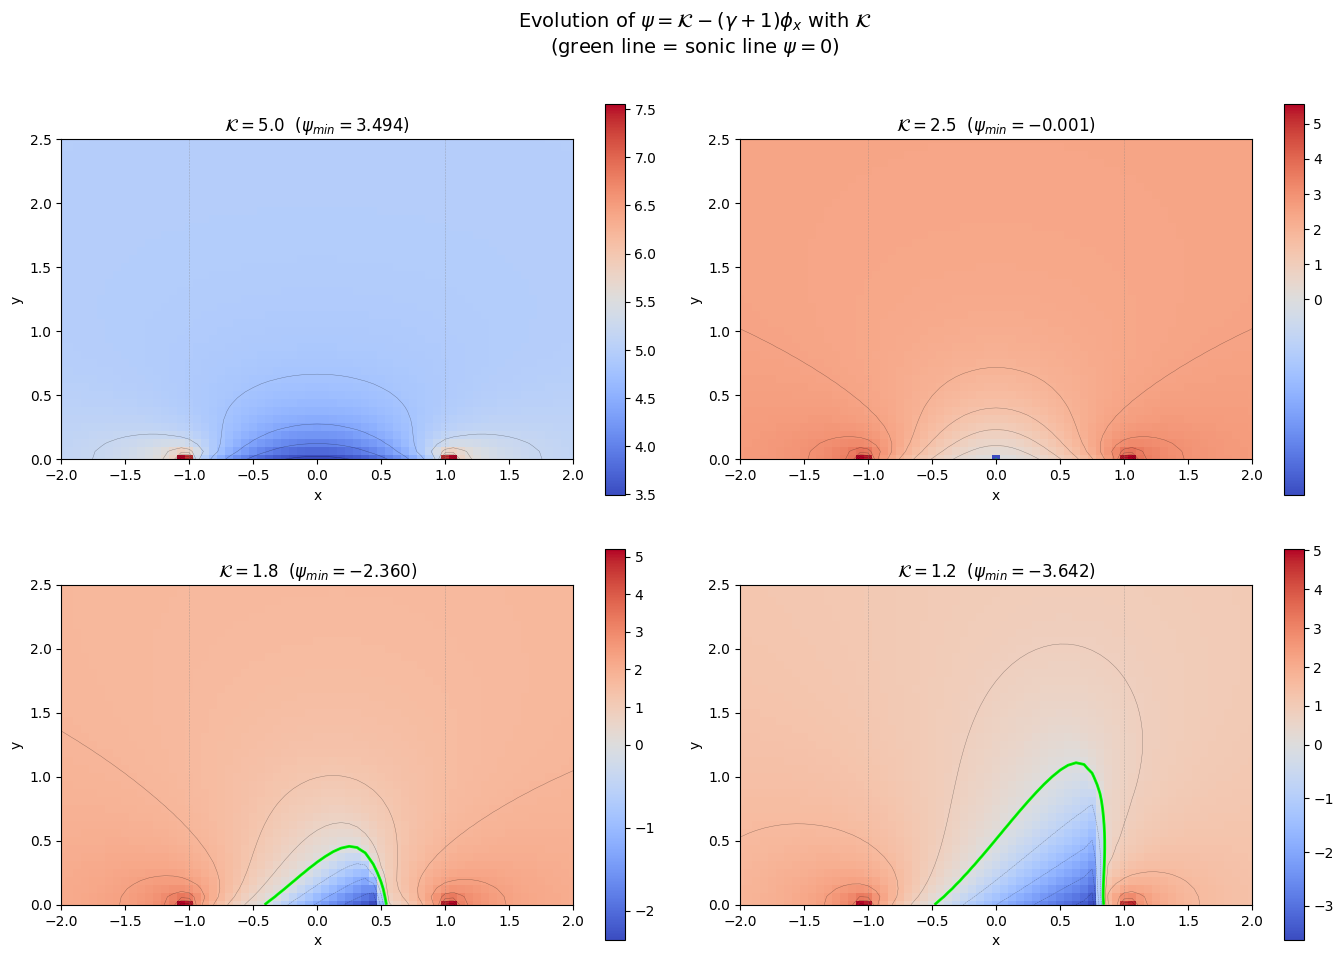

In [206]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, K in zip(axes.ravel(), K_plot):
    phi, info = solutions[K]
    x = info["x"]; y = info["y"]
    dx = info["dx"]
    X, Y = np.meshgrid(x, y, indexing="ij")

    phi_x = compute_phi_x(phi, dx)
    psi = compute_psi(phi_x, K)
    psi_min_val = psi.min(); psi_max_val = psi.max()

    if psi_min_val < 0 and psi_max_val > 0:
        norm_psi = TwoSlopeNorm(vmin=psi_min_val, vcenter=0, vmax=psi_max_val)
    else:
        norm_psi = None

    c = ax.pcolormesh(X, Y, psi, shading="auto", cmap="coolwarm", norm=norm_psi)
    if psi_min_val < 0:
        ax.contour(X, Y, psi, levels=[0], colors="lime", linewidths=2.0)
    ax.contour(X, Y, psi, levels=12, colors="k", linewidths=0.3, alpha=0.4)
    ax.set_title(rf"$\mathcal{{K}} = {K}$  ($\psi_{{min}} = {psi_min_val:.3f}$)", fontsize=12)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal"); ax.set_xlim(-2, 2); ax.set_ylim(0, 2.5)
    ax.axvline(-1, color="grey", ls="--", lw=0.4, alpha=0.5)
    ax.axvline( 1, color="grey", ls="--", lw=0.4, alpha=0.5)
    plt.colorbar(c, ax=ax, shrink=0.85)

plt.suptitle(r"Evolution of $\psi = \mathcal{K} - (\gamma+1)\phi_x$ with $\mathcal{K}$"
             "\n(green line = sonic line $\psi=0$)", fontsize=14)
plt.tight_layout()
plt.savefig("q3_p4_psi_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

Close-up $\phi_x$ contour for lowest K

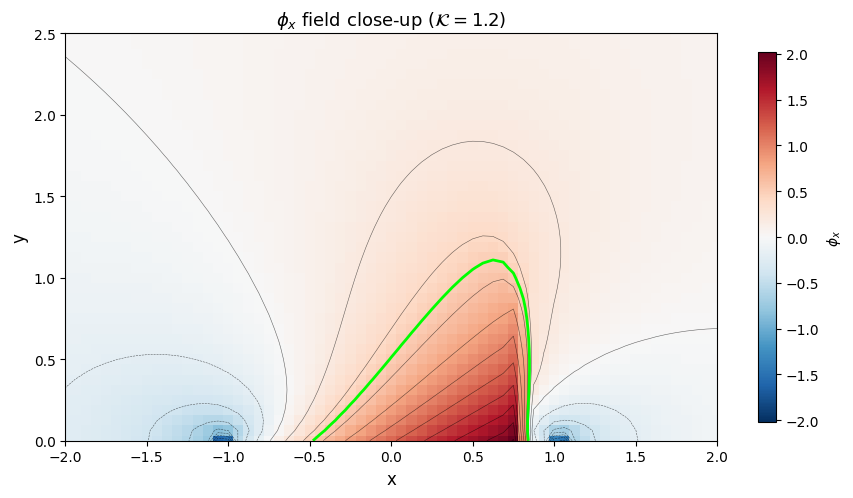

In [207]:
K_low = min(K_plot)
phi, info = solutions[K_low]
x = info["x"]; y = info["y"]
dx, dy = info["dx"], info["dy"]
X, Y = np.meshgrid(x, y, indexing="ij")
phi_x = compute_phi_x(phi, dx)

fig, ax = plt.subplots(figsize=(9, 5))
vmax = max(abs(phi_x.min()), abs(phi_x.max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
c = ax.pcolormesh(X, Y, phi_x, shading="auto", cmap="RdBu_r", norm=norm)
ax.contour(X, Y, phi_x, levels=20, colors="k", linewidths=0.4, alpha=0.6)
psi = compute_psi(phi_x, K_low)
if psi.min() < 0:
    ax.contour(X, Y, psi, levels=[0], colors="lime", linewidths=2.0)
ax.set_xlim(-2, 2); ax.set_ylim(0, 2.5)
ax.set_xlabel("x", fontsize=12); ax.set_ylabel("y", fontsize=12)
ax.set_title(rf"$\phi_x$ field close-up ($\mathcal{{K}}={K_low}$)", fontsize=13)
ax.set_aspect("equal")
plt.colorbar(c, ax=ax, label=r"$\phi_x$", shrink=0.85)
plt.tight_layout()
plt.savefig(f"q3_p4_phi_x_closeup_K{K_low:.1f}.png", dpi=150, bbox_inches="tight")
plt.show()